<a href="https://colab.research.google.com/github/humptybigdump/inprogress/blob/main/Kopie_von_05_3_ISE2025_Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Please make a copy of this notebook to try out your own adaptions via "File -> Save Copy in Drive"*

# **Word Embeddings**

In Sect. 2.12 2.12 Word Vectors II - Neural Language Models of the ISE 2025 lecture we introduce you to **word2vec word embeddings**.

In this colab notebook you will learn how to make use of the [SciKit Learn](https://scikit-learn.org/stable/) and the [gensim](https://radimrehurek.com/gensim/) library for applying machine learning algorithms, in particular for the **word2vec** (and other) **word embeddings**, and [mathplotlib](https://matplotlib.org/) to draw diagrams.


In [ ]:
#First loading all necessary libraries
%matplotlib inline
import urllib.request

!pip install gensim==4.3.0
import gensim
import gensim.downloader as api

# to visualize word vectors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
#helper function to draw a TSNE diagram of a word vector space
def plot_word_embeddings(model, search_list, offset):
    words = []
    for term in search_list:
        words += [w[0] for w in model.most_similar([term], topn=5)]
    words += search_list

    vectors = model[words]

    tsne = TSNE(n_components=2, random_state=0, n_iter=10000, perplexity=7)
    T = tsne.fit_transform(vectors)

    plt.figure(figsize=(16, 10))
    plt.scatter(T[:, 0], T[:, 1])
    for label, x, y in zip(words, T[:, 0], T[:, 1]):
        plt.annotate(label, xy=(x+offset, y+offset))

We are going to **load a pre-trained model** from gensim's model library. The easiest way to do so is via `gensim.downloader.load`.

First, let's see what models are available.

In [ ]:
# Show all available models in gensim-data
info = api.info()
print(list(info['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


We want to work with a [GoogleNews Word2Vec model](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing). [1]

However, the model's size is 1.6GB. Therefore, we have commented out the next code section and will load a smaller version of this original model. If you have sufficient time, you can uncomment the next code section and use the original model.

In [ ]:
#load Google News Word2Vec model
#model = api.load('word2vec-google-news-300')

Since this is **only a demo**, we have chosen a **smaller model** to load, which is not available from gensim's library. We have to download the compressed model, uncompress it, and then load the model.

The model we have chosen is an abbreviated GoogleNews model, [word2vec-slim](https://github.com/eyaler/word2vec-slim), that is restricted to a vocabulary of 300k words only (instead of 3M words for the original model).

*If you have already loaded the full model above, note that this will overwrite the full model again. So please skip this code block in case you want to continue with the full model.*

In [ ]:
#load pretrained model via URL
from gensim.models import KeyedVectors
import os

url = "https://github.com/eyaler/word2vec-slim/raw/master/GoogleNews-vectors-negative300-SLIM.bin.gz"
file_name = "GoogleNews300K-300.bin.gz"
if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
model = KeyedVectors.load_word2vec_format(file_name, binary=True)

Let's try out how the model is performing. We can start with a few similarity requests.

In [ ]:
print(model.similarity('woman', 'man'))

0.76640123


In [ ]:
print(model.similarity('icecream', 'climate'))

0.08234885


Now, we can also inspect the neighborhood of a vector by determining the most similar (via cosine similarity) vectors for a given vector.

In [ ]:
model.most_similar('knowledge', topn=10)

[('expertise', 0.6464043855667114),
 ('understanding', 0.6270676255226135),
 ('knowhow', 0.5822150707244873),
 ('experience', 0.5741491317749023),
 ('skills', 0.5266638994216919),
 ('insights', 0.5236833095550537),
 ('familiarity', 0.5105752944946289),
 ('insight', 0.507941484451294),
 ('acumen', 0.48420223593711853),
 ('knowledgeable', 0.4809471070766449)]

We can also directly determine the distance of two given vectors.

In [ ]:
model.distance('laugh', 'cry')

0.5967768728733063

Now, let's try some analogical reasoning, as we have seen in the lecture.

# king - man + woman = queen

In [ ]:
model.most_similar(positive=['king', 'woman'], negative=['male'])

[('queen', 0.5452350974082947),
 ('princess', 0.5137688517570496),
 ('monarch', 0.5011522173881531),
 ('prince', 0.4866582751274109),
 ('ruler', 0.46721190214157104),
 ('sultan', 0.4574386775493622),
 ('grandmother', 0.43675902485847473),
 ('man', 0.436735063791275),
 ('maharaja', 0.42895373702049255),
 ('kings', 0.42818260192871094)]

# Plural

In [ ]:
model.most_similar(positive=['dogs', 'fox'], negative=['dog'])

[('foxes', 0.8096246719360352),
 ('squirrels', 0.6606090664863586),
 ('rabbits', 0.622259795665741),
 ('birds', 0.5941581130027771),
 ('squirrel', 0.5821964740753174),
 ('cats', 0.5732661485671997),
 ('skunks', 0.5728775262832642),
 ('hares', 0.5725615620613098),
 ('coyotes', 0.5720279812812805),
 ('owls', 0.571752667427063)]

# Past Participle

In [ ]:
model.most_similar(positive=['eaten', 'learn'], negative=['eat'])

[('learned', 0.6145898699760437),
 ('learning', 0.5087051391601562),
 ('discover', 0.46591916680336),
 ('learns', 0.4579032063484192),
 ('taught', 0.43115293979644775),
 ('Learn', 0.41375112533569336),
 ('knowledge', 0.4030046761035919),
 ('discovered', 0.38045188784599304),
 ('discovering', 0.38038238883018494),
 ('forgotten', 0.3789037764072418)]

# Continuous Form

In [ ]:
model.most_similar(positive=['coming', 'go'], negative=['come'])

[('going', 0.6908147931098938),
 ('heading', 0.5980861783027649),
 ('Going', 0.5439997315406799),
 ('goes', 0.5228973627090454),
 ('went', 0.5224890112876892),
 ('gone', 0.5088217258453369),
 ('moving', 0.4709923267364502),
 ('goin', 0.46780940890312195),
 ('next', 0.4591950476169586),
 ('just', 0.455850213766098)]

# Capitals

In [ ]:
model.most_similar(positive=['paris', 'spain'], negative=['france'])

[('madrid', 0.5295541286468506),
 ('dubai', 0.509259819984436),
 ('heidi', 0.48901546001434326),
 ('portugal', 0.48763689398765564),
 ('paula', 0.4855714440345764),
 ('alex', 0.4807346761226654),
 ('lohan', 0.4801103472709656),
 ('diego', 0.48010098934173584),
 ('florence', 0.47695302963256836),
 ('costa', 0.4761490523815155)]

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


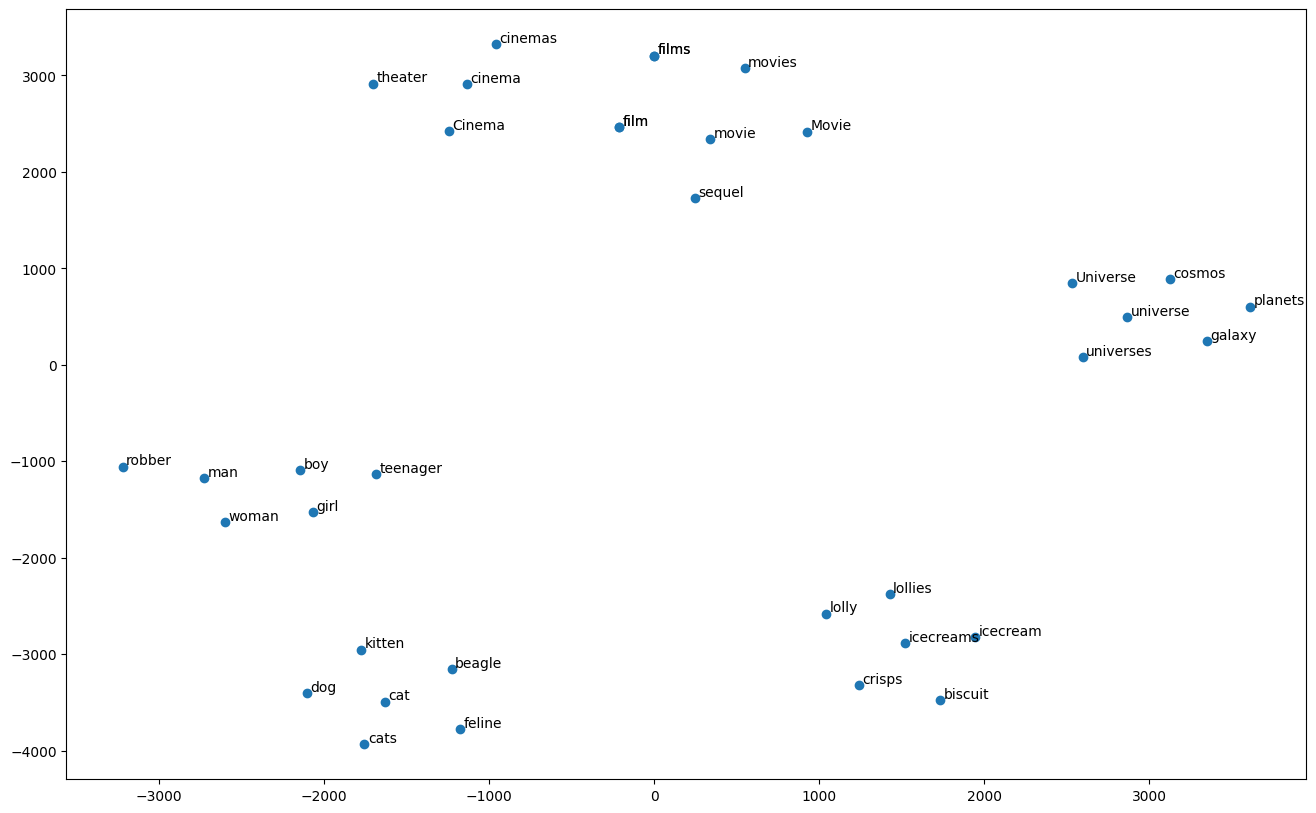

In [ ]:
search_list = ['man', 'icecream', 'cat', 'movie', 'cinema', 'universe']
plot_word_embeddings(model, search_list, 20)

Now, let's try out and train our own model.

First we have to download a small dataset. We are using the '`text8`' dataset (30MB) from gensim's dataset library. Then we train a standard Word2Vec model (this will take circa two minutes).

In [ ]:
# training a new (small) model
from gensim.models import Word2Vec

dataset = api.load("text8")  # load dataset as iterable
model2 = Word2Vec(dataset)  # train w2v model

[==================================================] 100.0% 31.6/31.6MB downloaded


... and play around with it.

In [ ]:
print(model2.wv.similarity('woman', 'man'))

0.7258732


In [ ]:
model2.wv.most_similar('climate', topn=10)

[('climatic', 0.7142782807350159),
 ('subtropical', 0.7117535471916199),
 ('temperate', 0.6811791062355042),
 ('tropical', 0.6614893078804016),
 ('humid', 0.6512322425842285),
 ('desertification', 0.6442461609840393),
 ('seasonal', 0.6417024731636047),
 ('droughts', 0.6412724256515503),
 ('biodiversity', 0.6409491896629333),
 ('warming', 0.6400061249732971)]

In [ ]:
model2.wv.most_similar(positive=['king', 'woman'], negative=['male'])

[('queen', 0.6494851112365723),
 ('prince', 0.636330246925354),
 ('duke', 0.6229275465011597),
 ('princess', 0.6144890189170837),
 ('pretender', 0.6045656800270081),
 ('tsar', 0.5929815769195557),
 ('castile', 0.5887837409973145),
 ('aragon', 0.5843732357025146),
 ('son', 0.581363320350647),
 ('regent', 0.5748330354690552)]

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


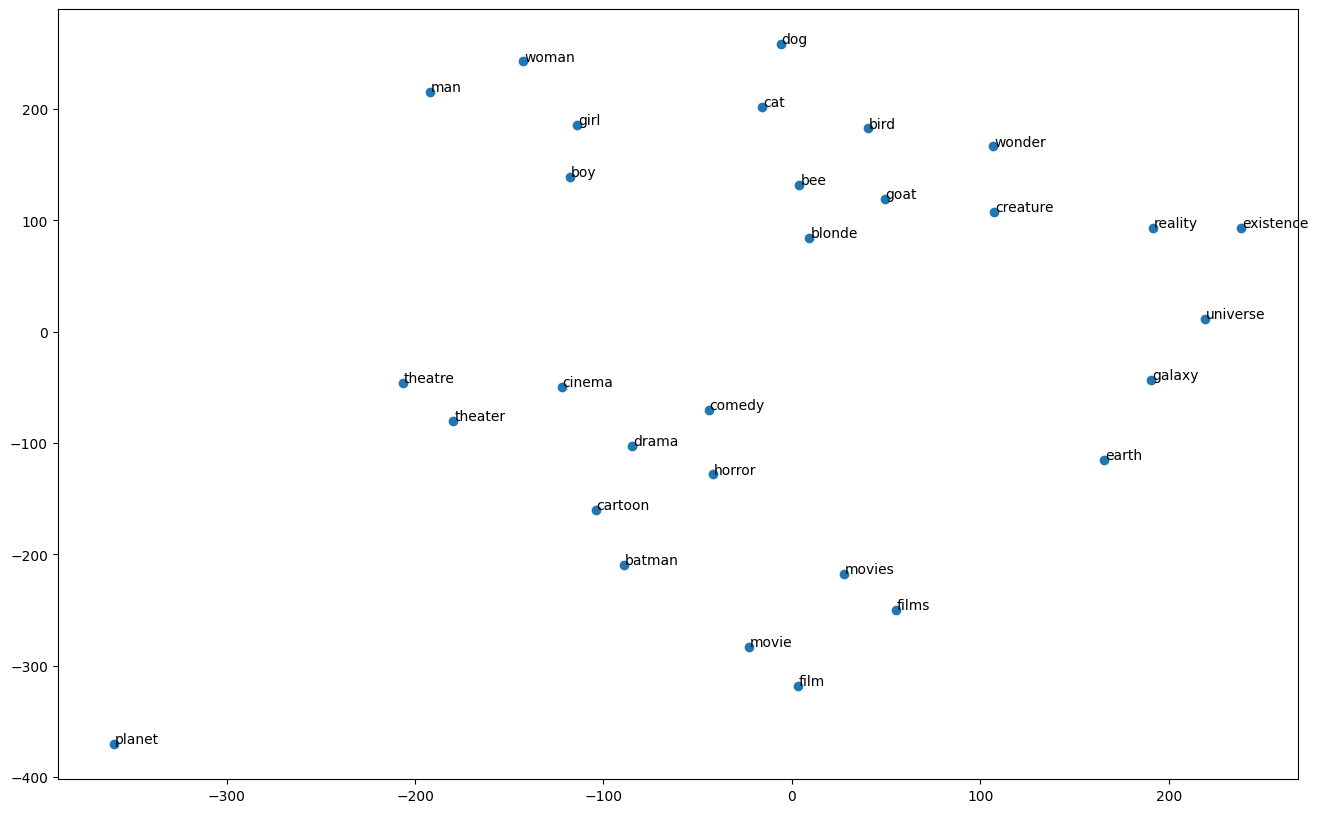

In [ ]:
search_list = ['man', 'cat', 'movie', 'cinema', 'universe']
plot_word_embeddings(model2.wv, search_list, 0.5)

# Bibliography:

- [1] [Word2Vec at Google Code Archive](https://code.google.com/archive/p/word2vec/)
- [2] Tomás Mikolov, Kai Chen, Greg Corrado, Jeffrey Dean: *Efficient Estimation of Word Representations in Vector Space*. ICLR (Workshop Poster) 2013, [download pdf](https://arxiv.org/pdf/1301.3781.pdf)
- [3] Tomás Mikolov, Ilya Sutskever, Kai Chen, Gregory S. Corrado, Jeffrey Dean: *Distributed Representations of Words and Phrases and their Compositionality*. NIPS 2013: 3111-3119, [download here](https://arxiv.org/pdf/1310.4546.pdf)